# Canopy Analysis

A Canopy Height Model (CHM) can be generated by subtracting the Digital Terrain Model (DTM) from the Digital Surface Model (DSM) for the region of interest:

**CHM = DSM − DTM**

This provides an estimate of vegetation height above ground level.

Additional vegetation characteristics can also be derived from elevation data, including:

- Canopy height – derived directly from the CHM
- Canopy distribution – the distribution of canopy heights across the ROI
- Canopy cover – the percentage of ground covered by canopy when viewed from above

In this notebook, canopy cover is estimated using Otsu’s thresholding method applied to the Canopy Height Model (CHM). Pixels exceeding a calculated threshold are classified as canopy, and the proportion of these pixels is used to derive percentage canopy cover.

Otsu's method automatically determines a threshold by:

- Minimises variance within groups 
- Maximises variance between groups

Effectively, separating the data into two classes, typically representing non-canopy (low heights) and canopy (higher 
vegetation).

### Limitations of Otsu’s Method

- A large proportion of zero or near-zero values can skew the threshold, often making it too high.
- Gradual transitions in vegetation height (no clear peaks) reduce the ability to separate canopy from non-canopy.

As a result, canopy extent may be under- or over-estimated when the data distribution is not clearly separable.

In [19]:
# Import required packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
import rasterio
from pathlib import Path
from skimage.filters import threshold_otsu


In [20]:
# set our working directory for data inputs

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "GIthub" / "data" / "nrfa_39088"

dtm_path = DATA_DIR/'dtm_39088_extract.tif'
dsm_path = DATA_DIR/'dsm_39088_extract.tif'

In [21]:

def plot_raster_with_histogram(raster_path: str, title: str, label: str, color_scheme: str):
    """ 
    Plot a raster with real-world extent, colour scaling and histogram.

    Parameters:
    raster_path : str
        Path to raster file
    title : str
        Title for the plot
    """

    # Load raster with rasterio to get georeferencing
    with rasterio.open(raster_path) as src:
        raster = src.read(1)  # Read the first band
        bounds = src.bounds  # Get raster bounding box
        nodata = src.nodata  # NoData value

    # Mask out NoData values
    if nodata is not None:
        valid_data = raster[raster != nodata]
    else:
        valid_data = raster[~np.isnan(raster)]

    if valid_data.size == 0:
        raise ValueError("No valid raster values found.")

    # Compute Color Normalization
    datamin = np.percentile(valid_data, 2)
    datamax = np.percentile(valid_data, 98)
    norm = colors.Normalize(vmin=datamin, vmax=datamax)
    cmap = color_scheme

    # Compute Real-World Extent
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    # Plot
    _, ax = plt.subplots(figsize=(10, 6))

    # Display the raster with real-world extent
    img = ax.imshow(raster, cmap=cmap, norm=norm, extent=extent, origin="upper")

    # Display the raster with real-world extent #img =
    ax.imshow(raster, cmap=cmap, norm=norm, extent=extent, origin="upper")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_title(title)
    
    # Create a colorbar
    cbar = plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(label)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = ax.inset_axes([1.3, 0.35, 0.06, 0.5])  # Position the colorbar inset
    cbar = plt.colorbar(sm, cax=cax)
    cbar.ax.tick_params(labelsize=8)
    cax.yaxis.set_ticks_position('right')
    cax.yaxis.set_label_position('right')

    # Histogram inset
    hax = ax.inset_axes([1.2, 0.05, 0.25, 0.25])
    colormap = plt.colormaps.get_cmap(cmap)

    # Filter raster values for histogram
    data = valid_data[(valid_data > datamin) & (valid_data < datamax)]

    # Plot % histogram
    n = len(data)
    _, bins, patches = hax.hist(data, bins=20, edgecolor='none', weights=np.ones(n)/n*100)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Normalize bin centers to [0, 1]
    col = (bin_centers - min(bin_centers)) / (max(bin_centers) - min(bin_centers))

    for c, p in zip(col, patches):
            plt.setp(p, 'facecolor', colormap(c))

    hax.set_xlabel('Elevation (m)')
    hax.set_ylabel('Occupation (%)')
    hax.yaxis.set_ticks_position('right')
    hax.yaxis.set_label_position('right')

    plt.tight_layout()
    plt.show()


In [22]:
# Function to load raster data
def load_raster(filepath):
    with rasterio.open(filepath) as src:
        data = src.read(1)  # Read first band
        meta = src.meta.copy()
    return data, meta

In [23]:
# Commpute the canopy height for the ROI
def compute_chm(dsm_path, dtm_path, chm_path):
    dsm, meta = load_raster(dsm_path)
    dtm, _ = load_raster(dtm_path)

    # Check alignment between the DSM and DTM
    if dsm.shape != dtm.shape:
        raise ValueError("DSM and DTM must have the same shape")

    # Compute CHM
    chm = dsm - dtm

    # Update metadata
    meta.update(dtype=rasterio.float32)

    # Write output
    with rasterio.open(chm_path, 'w', **meta) as dst:
        dst.write(chm.astype(rasterio.float32), 1)

    print(f"CHM written to {chm_path}")

    return chm_path

In [24]:
output_chm = compute_chm(dsm_path, dtm_path, '39088_chm.tif')

CHM written to 39088_chm.tif


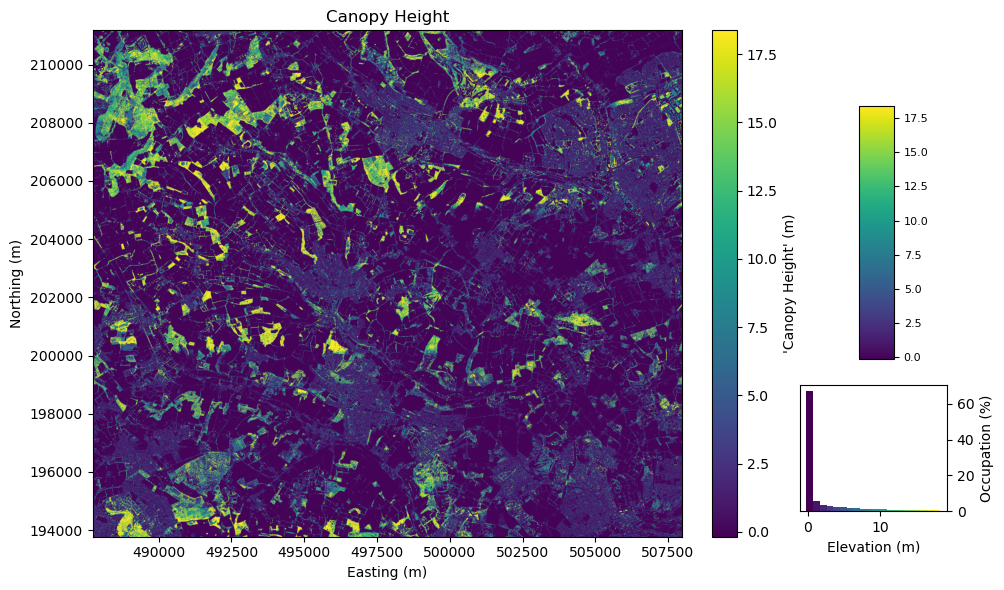

In [25]:
# Plot the canopy height model output using the plotting function
plot_raster_with_histogram(output_chm, title= 'Canopy Height', label="'Canopy Height' (m)", color_scheme="viridis")

Canopy Cover: 32.12%


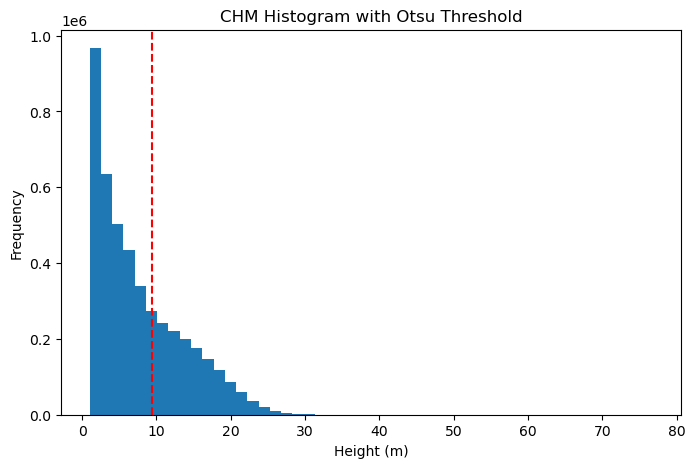

In [26]:
# Compute Canopy Cover percentage using Otsu's thresholding
# threshold_otsu finds a value the differentiates between low values for grass/ground and high values for canopy

# Read the first band from the canopy height model we generated 
with rasterio.open(output_chm, 'r') as src:
    chm = src.read(1) #grid of height values
    nodata = src.nodata

# Define valid pixels with a boolean mask: keep all postive values and ignore no data  
# remove some of the noise by selecting a slightly higher postive value e.g instead of 0
valid_mask = (chm != nodata) & (chm > 1)

# Extact the valid data using the mask and find the otsu threshold within this data
threshold = threshold_otsu(chm[valid_mask])

# create the binary mask where high values (canopy) are present from only valid pixels.
canopy_cover = (chm > threshold) & valid_mask

# Compute percentage cover from canopy pixels and all positive/valid pixels.
canopy_percentage = np.sum(canopy_cover) / np.sum(valid_mask) * 100

print(f"Canopy Cover: {canopy_percentage:.2f}%")

# Create subplots for results
plt.figure(figsize=(8,5))

# Histogram and Otsu's threshold
plt.hist(chm[valid_mask], bins=50)
plt.axvline(threshold, color='red', linestyle='--')

plt.title("CHM Histogram with Otsu Threshold")
plt.xlabel("Height (m)")
plt.ylabel("Frequency")

plt.show()

Mean Canopy Height: 14.91 m
Max Canopy Height: 76.83 m


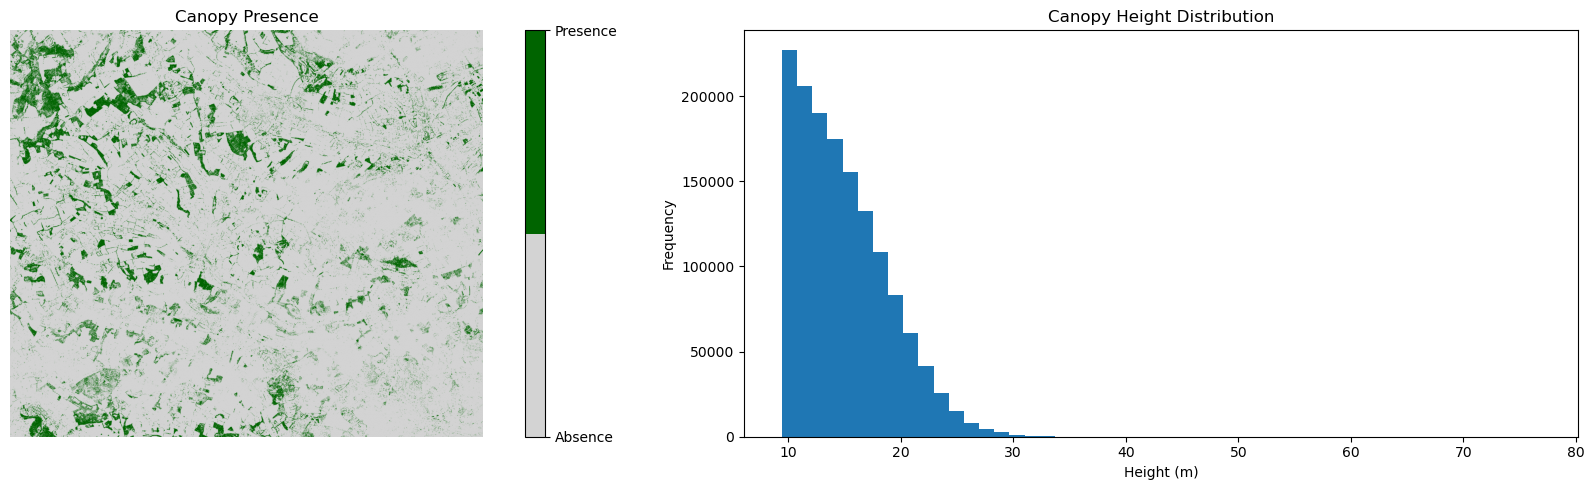

In [27]:
# Create subplots for results
fig, axes = plt.subplots(1, 2, figsize=(18,5))

# Canopy Presence/Absense
im = axes[0].imshow(canopy_cover, cmap = ListedColormap(['lightgrey','darkgreen']))
axes[0].set_title("Canopy Presence")
axes[0].axis("off")

cbar = fig.colorbar(im, ax=axes[0])
cbar.set_ticks([0,1])
cbar.set_ticklabels(['Absence' ,'Presence'])

# Extract canopy height statistics
canopy_heights = chm[chm > threshold]
mean_height = np.mean(canopy_heights)
max_height = np.max(canopy_heights)
print(f"Mean Canopy Height: {mean_height:.2f} m")
print(f"Max Canopy Height: {max_height:.2f} m")

# Canopy Height Distribution 
axes[1].hist([canopy_heights], bins =50)
axes[1].set_title("Canopy Height Distribution")
axes[1].set_xlabel("Height (m)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()